# 02. Các Mô Hình Machine Learning

Huấn luyện và so sánh 7 mô hình Machine learning trên 59 engineered features.  
Mỗi mô hình được đánh giá bằng Accuracy, F1-weighted và F1-macro.

**Models:** KNN · Naive Bayes · Decision Tree · SVM · Logistic Regression · MLP · Random Forest

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../final_dataset_with_all_features_v3.1.csv')
df_tab = df.drop(columns=['url', 'type', 'domain', 'scan_date'])
df_tab = df_tab.fillna(df_tab.median(numeric_only=True))

X = df_tab.drop(columns=['label'])
y = df_tab['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns)

## 2. Hàm Đánh Giá Chung

Định nghĩa hàm dùng chung cho tất cả model bên dưới.

In [3]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
def evaluate_model(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall: {rec*100:.2f}%")
    print(f"F1-Score : {f1*100:.2f}%")
    print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Defacement','Phishing','Malware'],
                yticklabels=['Benign','Defacement','Phishing','Malware'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1}
# Lưu kết quả tất cả mô hình
results = []

## 3. KNN


KNN
Accuracy : 91.48%
Precision: 91.06%
Recall: 91.48%
F1-Score : 91.14%

              precision    recall  f1-score   support

           0       0.93      0.96      0.95     85621
           1       0.95      0.98      0.96     19292
           2       0.77      0.63      0.69     18822
           3       0.97      0.92      0.94      6504

    accuracy                           0.91    130239
   macro avg       0.90      0.87      0.89    130239
weighted avg       0.91      0.91      0.91    130239



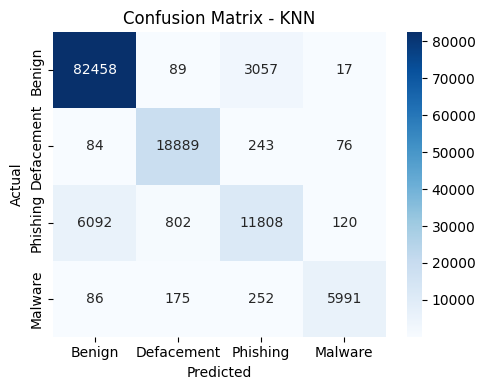

In [8]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results.append(evaluate_model('KNN', y_test, y_pred_knn))

## 4. Naive Bayes


Naive Bayes
Accuracy : 80.48%
Precision: 79.03%
Recall: 80.48%
F1-Score : 76.16%

              precision    recall  f1-score   support

           0       0.84      0.93      0.88     85621
           1       0.72      0.98      0.83     19292
           2       0.67      0.09      0.16     18822
           3       0.70      0.75      0.72      6504

    accuracy                           0.80    130239
   macro avg       0.73      0.69      0.65    130239
weighted avg       0.79      0.80      0.76    130239



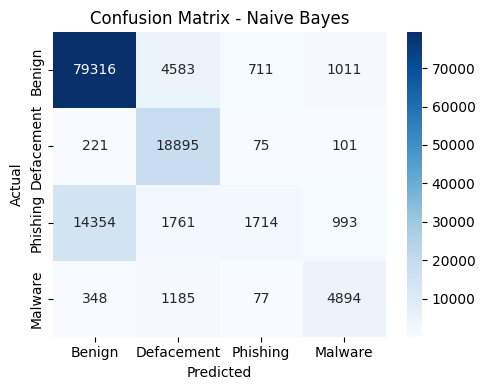

In [9]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
results.append(evaluate_model('Naive Bayes', y_test, y_pred_nb))

## 5. Decision Tree


Decision Tree
Accuracy : 87.27%
Precision: 86.90%
Recall: 87.27%
F1-Score : 84.87%

              precision    recall  f1-score   support

           0       0.87      0.99      0.93     85621
           1       0.88      0.96      0.92     19292
           2       0.82      0.28      0.42     18822
           3       0.96      0.80      0.87      6504

    accuracy                           0.87    130239
   macro avg       0.88      0.76      0.78    130239
weighted avg       0.87      0.87      0.85    130239



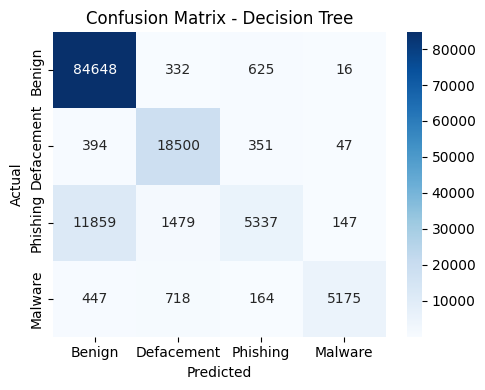

In [10]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))

## 6. SVM


SVM
Accuracy : 84.54%
Precision: 84.27%
Recall: 84.54%
F1-Score : 80.27%

              precision    recall  f1-score   support

           0       0.85      0.99      0.91     85621
           1       0.84      0.96      0.90     19292
           2       0.82      0.13      0.22     18822
           3       0.85      0.72      0.78      6504

    accuracy                           0.85    130239
   macro avg       0.84      0.70      0.70    130239
weighted avg       0.84      0.85      0.80    130239



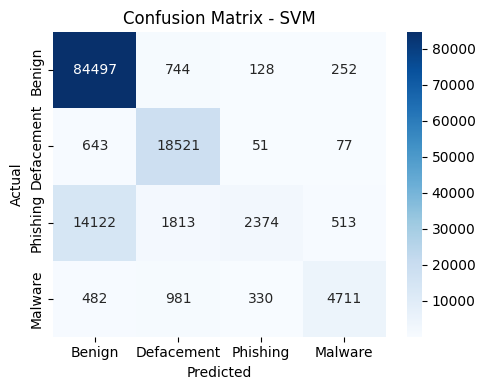

In [11]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
results.append(evaluate_model('SVM', y_test, y_pred_svm))

## 7. Logistic Regression


Logistic Regression
Accuracy : 84.78%
Precision: 83.75%
Recall: 84.78%
F1-Score : 80.90%

              precision    recall  f1-score   support

           0       0.85      0.99      0.91     85621
           1       0.86      0.96      0.90     19292
           2       0.76      0.15      0.25     18822
           3       0.87      0.74      0.80      6504

    accuracy                           0.85    130239
   macro avg       0.83      0.71      0.72    130239
weighted avg       0.84      0.85      0.81    130239



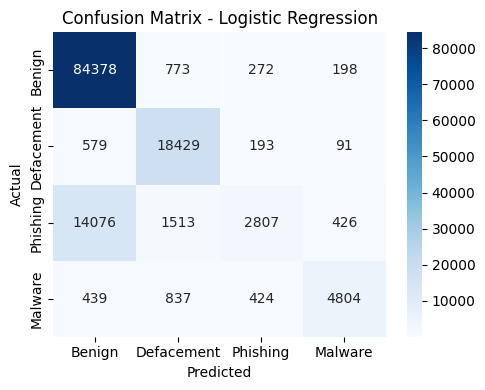

In [12]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
results.append(evaluate_model('Logistic Regression', y_test, y_pred_log_reg))

## 8. Neural Network (MLP)


Neural Network (MLP)
Accuracy : 92.39%
Precision: 92.09%
Recall: 92.39%
F1-Score : 91.88%

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     85621
           1       0.95      0.98      0.97     19292
           2       0.85      0.61      0.71     18822
           3       0.97      0.91      0.94      6504

    accuracy                           0.92    130239
   macro avg       0.92      0.87      0.89    130239
weighted avg       0.92      0.92      0.92    130239



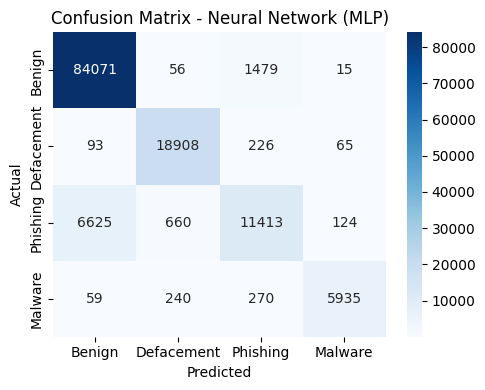

In [13]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300,
                    random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
results.append(evaluate_model('Neural Network (MLP)', y_test, y_pred_mlp))

## 9. Random Forest


Random Forest
Accuracy : 92.63%
Precision: 92.29%
Recall: 92.63%
F1-Score : 92.26%

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     85621
           1       0.96      0.98      0.97     19292
           2       0.82      0.64      0.72     18822
           3       0.98      0.94      0.96      6504

    accuracy                           0.93    130239
   macro avg       0.92      0.89      0.90    130239
weighted avg       0.92      0.93      0.92    130239



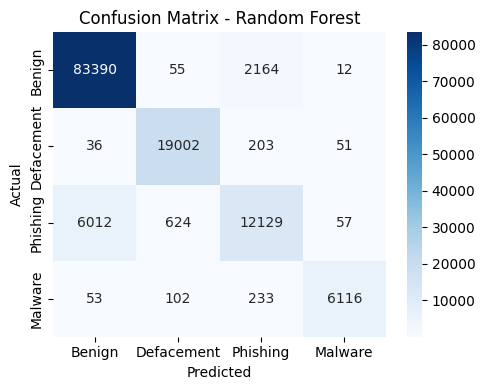

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

## 10. Feature Importance Random Forest
Top 15 features ảnh hưởng nhiều nhất đến quyết định của Random Forest.

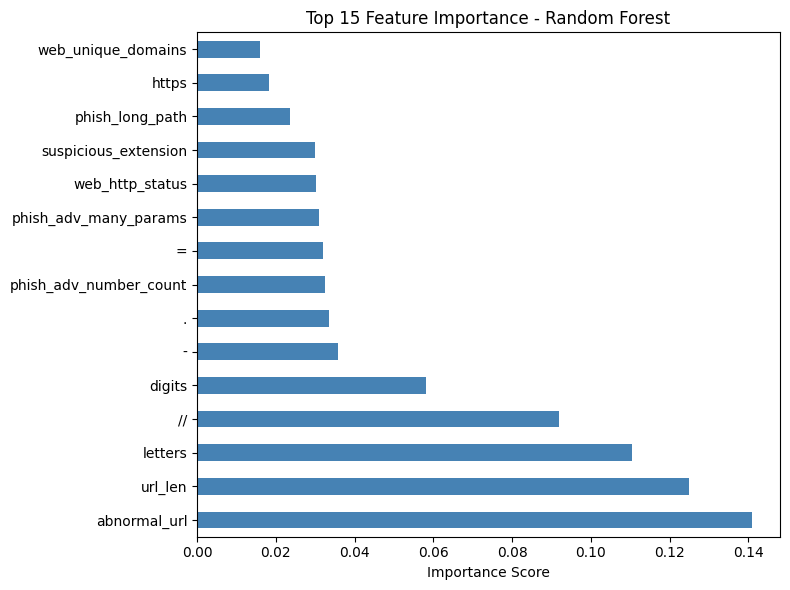

In [19]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 6))
feat_imp.nlargest(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 11. So Sánh Tổng Hợp 7 Mô Hình

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def get_metrics(name, y_test, y_pred):
    return {
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
results = [
    get_metrics('KNN', y_test, y_pred_knn),
    get_metrics('Naive Bayes', y_test, y_pred_nb),
    get_metrics('Decision Tree', y_test, y_pred_dt),
    get_metrics('SVM', y_test, y_pred_svm),
    get_metrics('Logistic Regression', y_test, y_pred_log_reg),
    get_metrics('Neural Network (MLP)', y_test, y_pred_mlp),
    get_metrics('Ensemble (Random Forest)', y_test, y_pred_rf),
]
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1

df_display = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_display[col] = df_display[col].apply(lambda x: f"{x*100:.2f}%")

print("=== BẢNG SO SÁNH TỔNG HỢP 7 MÔ HÌNH ===")
print(df_display.to_string())

=== BẢNG SO SÁNH TỔNG HỢP 7 MÔ HÌNH ===
                    Mô hình Accuracy Precision  Recall F1-Score
1  Ensemble (Random Forest)   92.63%    92.29%  92.63%   92.26%
2      Neural Network (MLP)   92.39%    92.09%  92.39%   91.88%
3                       KNN   91.48%    91.06%  91.48%   91.14%
4             Decision Tree   87.27%    86.90%  87.27%   84.87%
5       Logistic Regression   84.78%    83.75%  84.78%   80.90%
6                       SVM   84.54%    84.27%  84.54%   80.27%
7               Naive Bayes   80.48%    79.03%  80.48%   76.16%


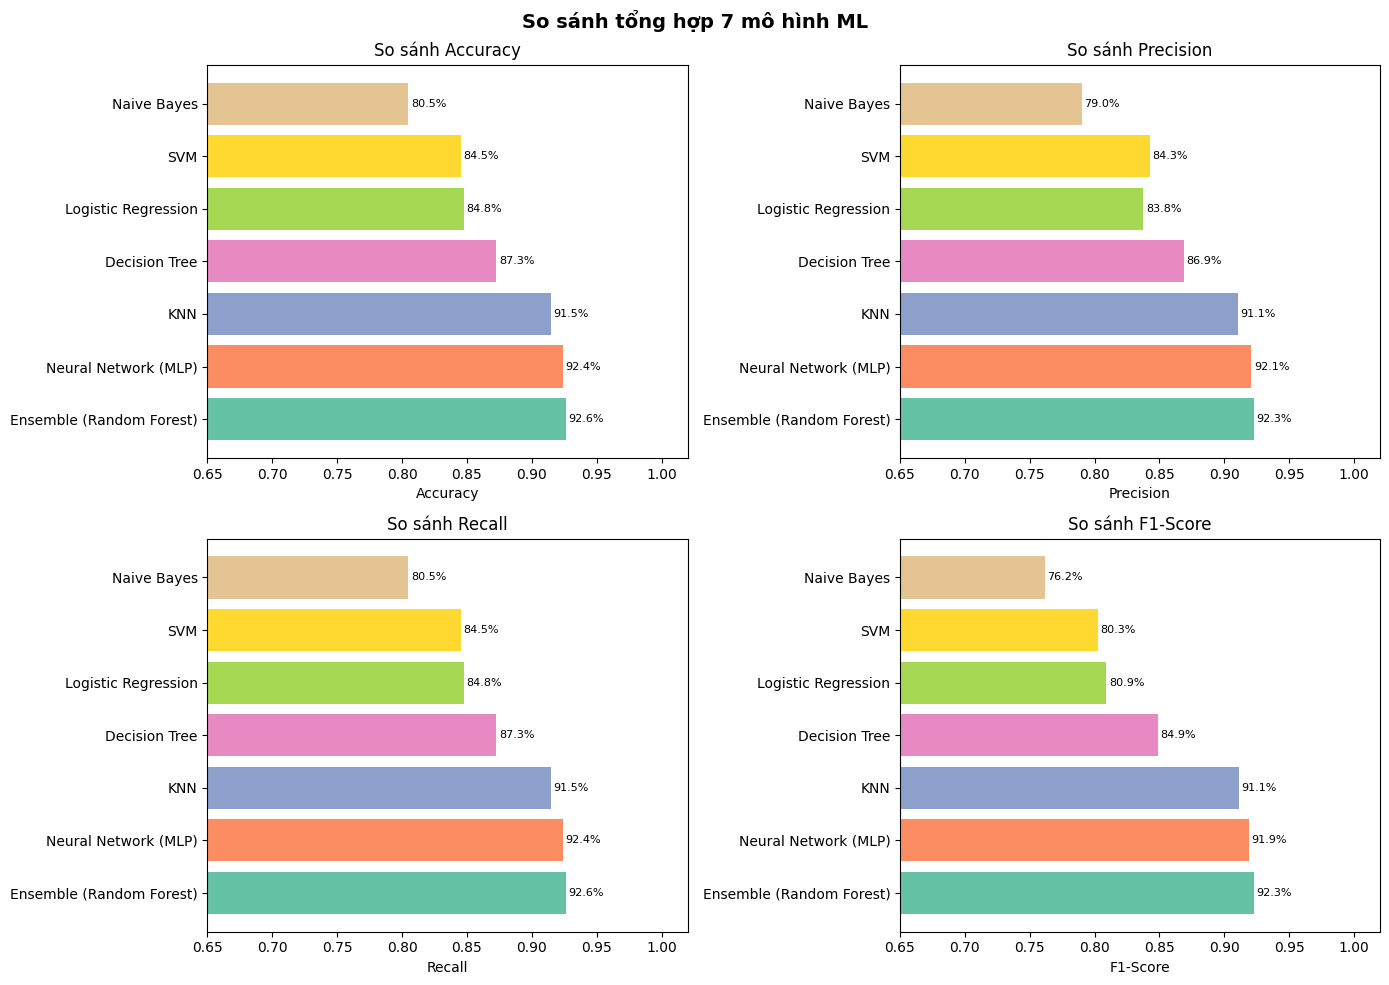

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = plt.cm.Set2.colors[:8]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    bars = ax.barh(df_results['Mô hình'], df_results[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'So sánh {metric}')
    ax.set_xlim(0.65, 1.02)
    for bar, v in zip(bars, df_results[metric]):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v*100:.1f}%', va='center', fontsize=8)

plt.suptitle('So sánh tổng hợp 7 mô hình ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()